In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,ConfusionMatrixDisplay,mean_absolute_error,mean_squared_error,r2_score

In [22]:
print("test")

test


In [23]:
df = pd.read_csv("datasets/breast_cancer.csv")
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [24]:
df.drop(columns=["id","Unnamed: 32"],inplace=True)
df['diagnosis'] = df["diagnosis"].map({'B':0,'M':1})
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [25]:
df.nunique()

diagnosis                    2
radius_mean                456
texture_mean               479
perimeter_mean             522
area_mean                  539
smoothness_mean            474
compactness_mean           537
concavity_mean             537
concave points_mean        542
symmetry_mean              432
fractal_dimension_mean     499
radius_se                  540
texture_se                 519
perimeter_se               533
area_se                    528
smoothness_se              547
compactness_se             541
concavity_se               533
concave points_se          507
symmetry_se                498
fractal_dimension_se       545
radius_worst               457
texture_worst              511
perimeter_worst            514
area_worst                 544
smoothness_worst           411
compactness_worst          529
concavity_worst            539
concave points_worst       492
symmetry_worst             500
fractal_dimension_worst    535
dtype: int64

In [26]:
df.value_counts()

diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  compactness_mean  concavity_mean  concave points_mean  symmetry_mean  fractal_dimension_mean  radius_se  texture_se  perimeter_se  area_se  smoothness_se  compactness_se  concavity_se  concave points_se  symmetry_se  fractal_dimension_se  radius_worst  texture_worst  perimeter_worst  area_worst  smoothness_worst  compactness_worst  concavity_worst  concave points_worst  symmetry_worst  fractal_dimension_worst
1          17.99        10.38         122.80          1001.0     0.11840          0.27760           0.30010         0.14710              0.2419         0.07871                 1.0950     0.9053      8.589         153.40   0.006399       0.04904         0.05373       0.01587            0.03003      0.006193              25.380        17.33          184.60           2019.0      0.16220           0.66560            0.7119           0.2654                0.4601          0.11890                    1
     

In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    int64  
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  569 non-null

In [28]:
from sklearn.datasets import load_breast_cancer
from sklearn.neighbors import KNeighborsClassifier

X= df.drop("diagnosis",axis=1)
y = df["diagnosis"]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

scaler_c = StandardScaler()

X_train_scaled = scaler_c.fit_transform(X_train)
X_test_scaled = scaler_c.transform(X_test)


In [29]:
knn_classifier = KNeighborsClassifier(n_neighbors=5)

knn_classifier.fit(X_train_scaled,y_train)
y_pred_c = knn_classifier.predict(X_test_scaled)

print("5 Nearest Neighbours Classifier results")
print(f"Accuracy: {accuracy_score(y_test,y_pred_c):.4f}\n")
print(classification_report(y_test,y_pred_c,target_names=["Benignant (0)","Malignant(1)"]))

5 Nearest Neighbours Classifier results
Accuracy: 0.9561

               precision    recall  f1-score   support

Benignant (0)       0.95      0.99      0.97        72
 Malignant(1)       0.97      0.90      0.94        42

     accuracy                           0.96       114
    macro avg       0.96      0.95      0.95       114
 weighted avg       0.96      0.96      0.96       114



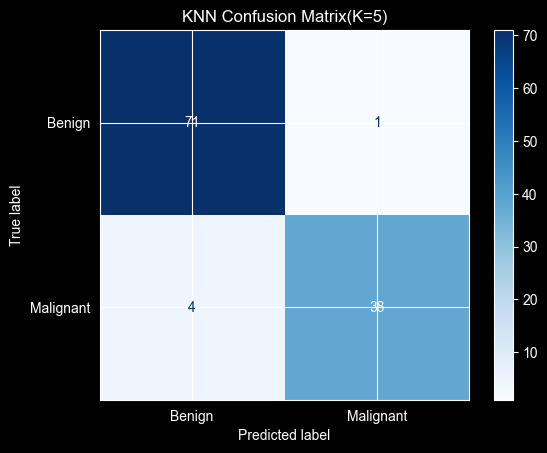

In [30]:
cm = confusion_matrix(y_test,y_pred_c)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["Benign","Malignant"])
disp.plot(cmap="Blues")
plt.title("KNN Confusion Matrix(K=5)")
plt.show()

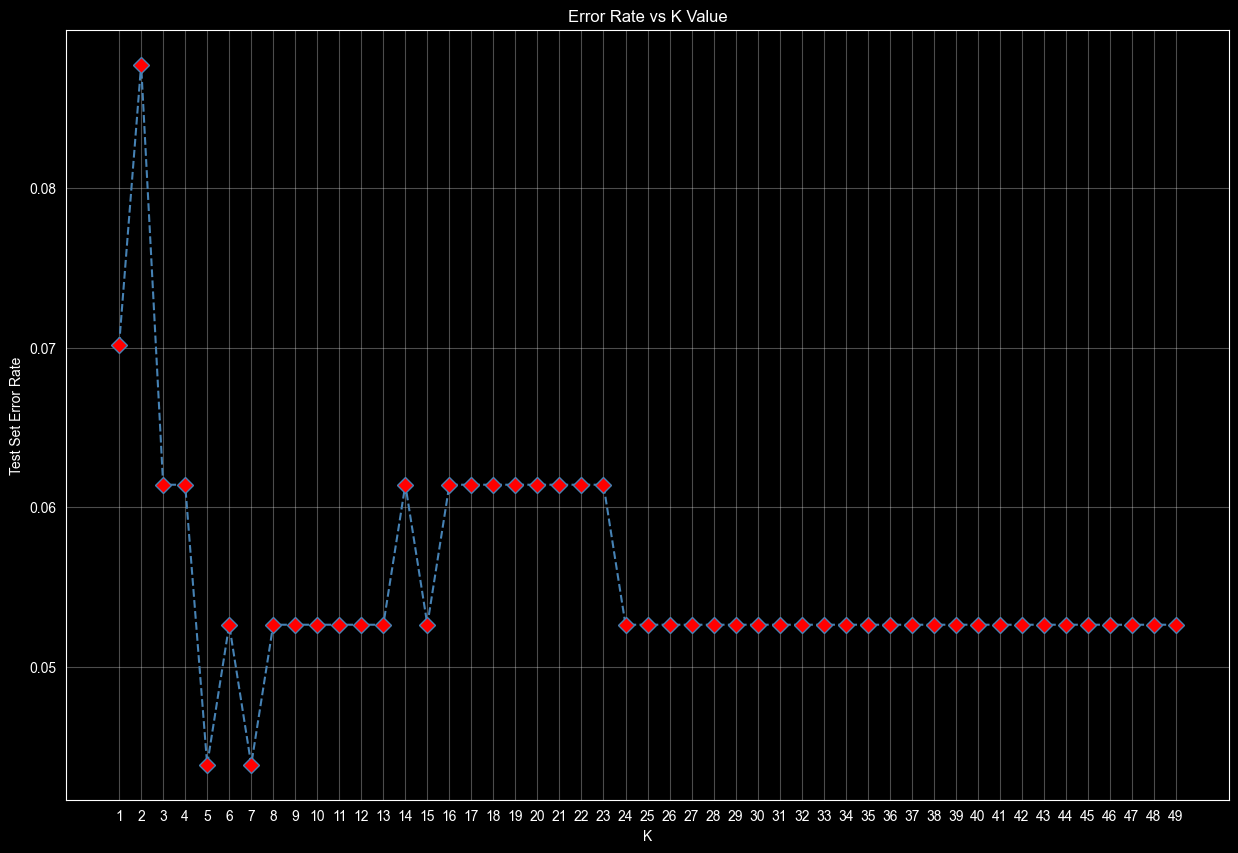

In [31]:

error_rates = []
k_values = range(1,50)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled,y_train)

    pred_i = knn.predict(X_test_scaled)
    error = np.mean(pred_i != y_test)
    error_rates.append(error)

plt.figure(figsize=(15,10))
plt.plot(k_values,error_rates,color="steelblue",linestyle="dashed",marker="D",markerfacecolor="red",markersize=8)
plt.title("Error Rate vs K Value")
plt.xlabel("K")
plt.ylabel("Test Set Error Rate")
plt.xticks(k_values)
plt.grid(True,alpha=0.3)
plt.show()

In [32]:
from sklearn.neighbors import KNeighborsRegressor

df_ins = pd.read_csv("datasets/insurance.csv")


In [33]:
df_ins.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [34]:
df_ins["smoker"] =df_ins["smoker"].map({"yes":1,"no":0})
df_ins["sex"]= df_ins["sex"].map({"female":1,"male":0})

X_reg = df_ins.drop("charges",axis=1)
y_reg = df_ins["charges"]

X_train_reg,X_test_reg,y_train_reg,y_test_reg = train_test_split(X_reg,y_reg,test_size=0.2,train_size=0.8,random_state=42)

ohe = OneHotEncoder(drop="first",sparse_output=False)
scaler_r = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ("num",scaler_r,["age","bmi","children"]),
        ("cat",ohe,["region"])
    ],
    remainder="passthrough"
)

In [35]:
X_train_r_scaled = preprocessor.fit_transform(X_train_reg)
X_test_r_scaled = preprocessor.transform(X_test_reg)

In [36]:
X_train_r_scaled.shape

(1070, 8)

In [37]:
X_test_r_scaled.shape

(268, 8)

In [38]:
X_train_r_scaled

array([[ 0.47222651, -1.75652513,  0.73433626, ...,  0.        ,
         1.        ,  0.        ],
       [ 0.54331294, -1.03308239, -0.91119211, ...,  0.        ,
         1.        ,  0.        ],
       [ 0.8987451 , -0.94368672, -0.91119211, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [ 1.3252637 , -0.89153925, -0.91119211, ...,  0.        ,
         0.        ,  0.        ],
       [-0.16755139,  2.82086429,  0.73433626, ...,  1.        ,
         1.        ,  1.        ],
       [ 1.1120044 , -0.10932713, -0.91119211, ...,  1.        ,
         0.        ,  0.        ]], shape=(1070, 8))

In [39]:
def regression_report(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print("Regresyon Performans Raporu")
    print("-" * 30)
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R2   : {r2:.4f}")
    print("-" * 30)

In [42]:
knn_regressor = KNeighborsRegressor(n_neighbors=5)
knn_regressor.fit(X_train_r_scaled,y_train_reg)
y_pred_r = knn_regressor.predict(X_test_r_scaled)

In [43]:
regression_report(y_test_reg,y_pred_r)

Regresyon Performans Raporu
------------------------------
MAE  : 3891.0525
MSE  : 46285808.7777
RMSE : 6803.3675
R2   : 0.7019
------------------------------
